# 1. Pradiusogradiusam to obtain the histogradiusam

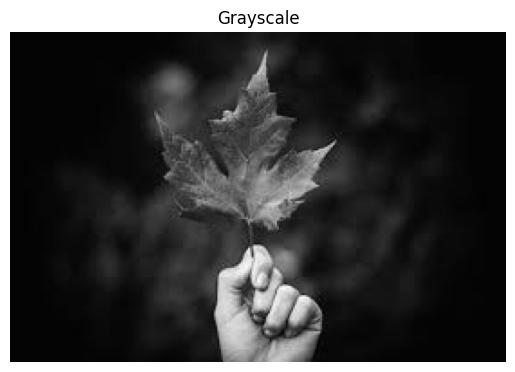

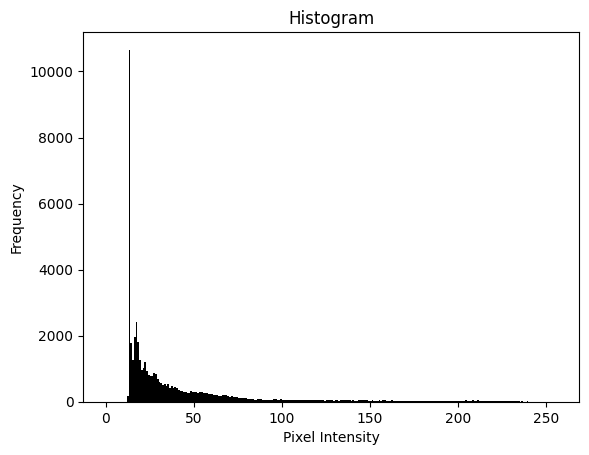

In [5]:
import cv2
import matplotlib.pyplot as plt
#read the image
I = cv2.imread('/content/image.jpg')
# Convert the image to grayscale
J = cv2.cvtColor(I, cv2.COLOR_BGR2GRAY)
# Display the grayscale image
plt.figure()
plt.imshow(J, cmap='gray')
plt.title('Grayscale')
plt.axis('off') # Hide axis
plt.show()
# Display the histogram
plt.figure()
plt.hist(J.ravel(), bins=256, range=[0, 256], color='black')
plt.title('Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()

# 2. Pradiusogradiusam to peradiusforadiusm histogradiusam equalization

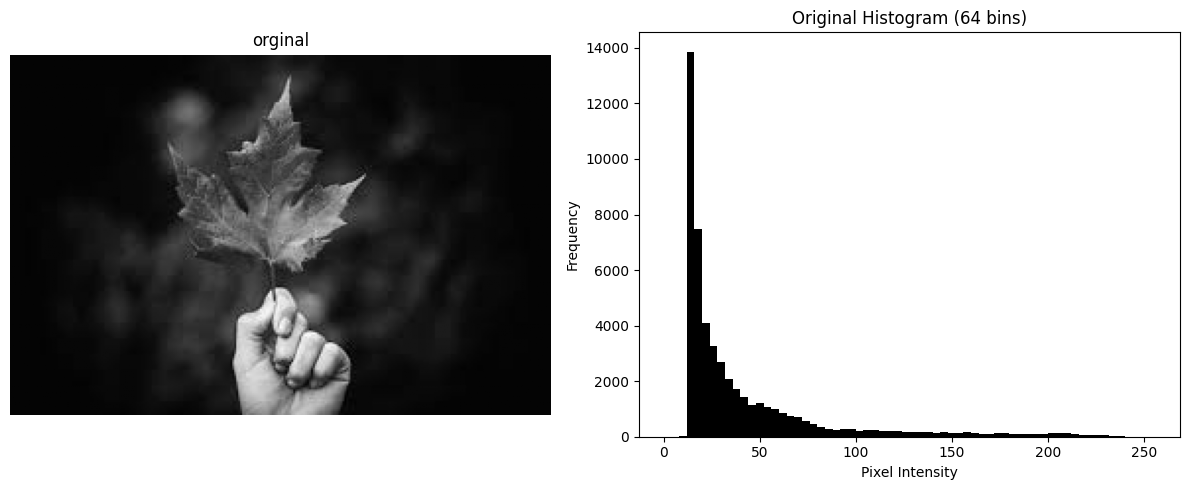

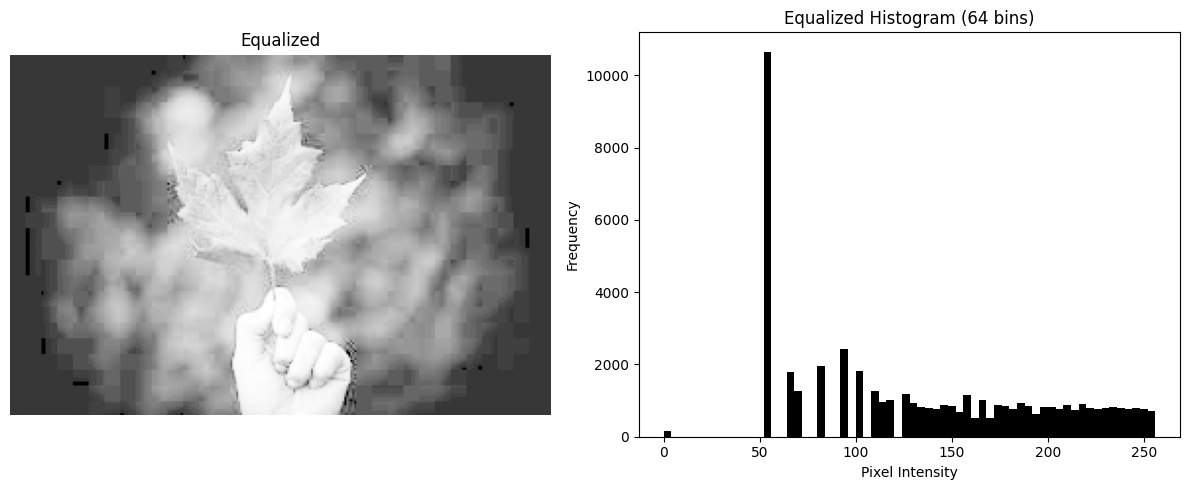

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# Helper function to compute histogram and CDF for grayscale image

def compute_hist_cdf(image, bins=256):
  hist, bin_edges = np.histogram(image.flatten(), bins=bins, range=[0,bins])
  cdf = hist.cumsum()
  # Normalize cdf
  cdf_normalized = cdf / cdf[-1]
  return hist, cdf_normalized
# Read the image
A = cv2.imread('image.jpg')
# Convert to grayscale
I = cv2.cvtColor(A, cv2.COLOR_BGR2GRAY)
# Display original grayscale image and histogram (64 bins)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(I, cmap='gray')
plt.title('orginal')
plt.axis('off')
plt.subplot(1,2,2)
plt.hist(I.ravel(), bins=64, range=[0,256], color='black')
plt.title('Original Histogram (64 bins)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
# Histogram equalization
J = cv2.equalizeHist(I)
# Display equalized image and histogram (64 bins)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(J, cmap='gray')
plt.title('Equalized')
plt.axis('off')
plt.subplot(1,2,2)
plt.hist(J.ravel(), bins=64, range=[0,256], color='black')
plt.title('Equalized Histogram (64 bins)')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

3.Program to compte Fourier transform and inverse Fourier Transform and visualize the magnitude and phase response

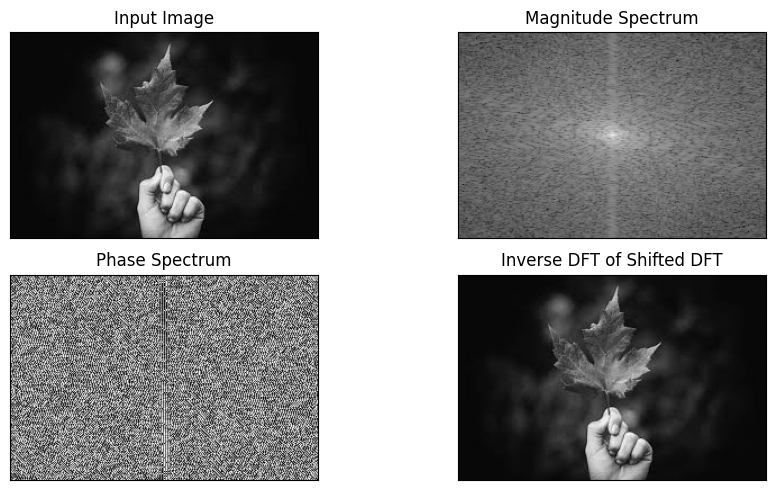

In [7]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

image = cv2.imread('/content/image.jpg', cv2.IMREAD_GRAYSCALE)

dft = np.fft.fft2(image)
dft_shift = np.fft.fftshift(dft)
magnitude_spectrum = 20 * np.log(np.abs(dft_shift))
phase_spectrum = np.angle(dft_shift)

idft_shift_original = np.fft.ifftshift(dft_shift)
idft_original = np.fft.ifft2(idft_shift_original)
idft_original = np.abs(idft_original)

plt.figure(figsize=(10, 5))

plt.subplot(221)
plt.imshow(image, cmap='gray')
plt.title('Input Image')
plt.xticks([])
plt.yticks([])

plt.subplot(222)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')
plt.xticks([])
plt.yticks([])

plt.subplot(223)
plt.imshow(phase_spectrum, cmap='gray')
plt.title('Phase Spectrum')
plt.xticks([])
plt.yticks([])

plt.subplot(224)
plt.imshow(idft_original, cmap='gray')
plt.title('Inverse DFT of Shifted DFT')
plt.xticks([])
plt.yticks([])

plt.tight_layout()
plt.show()

# 4.Program to use various smoothing and sharping filters and visualize its effect

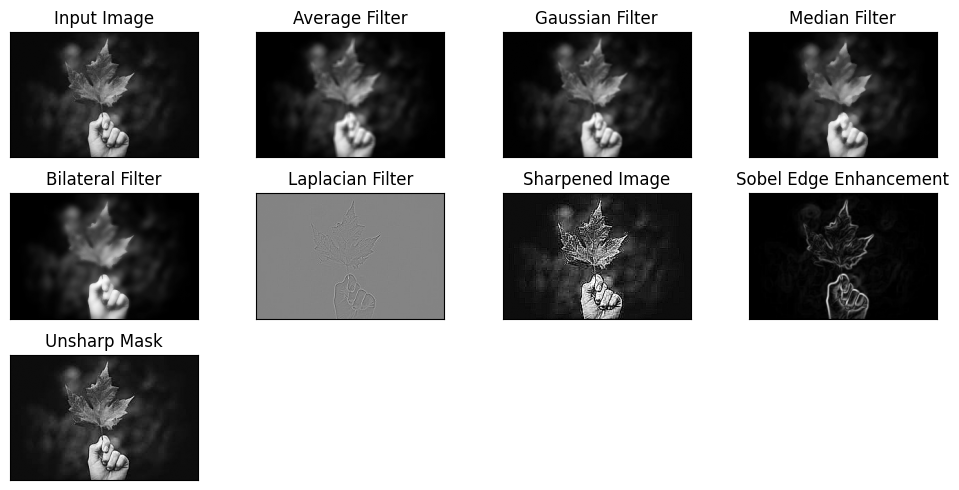

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(10, 5))
plt.subplot(341)
plt.imshow(image, cmap='gray')
plt.title('Input Image')
plt.xticks([])
plt.yticks([])
# smoothing filters
# averaging (Box) filter
avg_filter = cv2.blur(image, (5,5))
plt.subplot(342)
plt.imshow(avg_filter, cmap='gray')
plt.title('Average Filter')
plt.xticks([])
plt.yticks([])
# Gaussian filter
gaussian_filter = cv2.GaussianBlur(image, (5,5), 0)
plt.subplot(343)
plt.imshow(gaussian_filter, cmap='gray')
plt.title('Gaussian Filter')
plt.xticks([])
plt.yticks([])
# Median filter
median_filter = cv2.medianBlur(image, 5)
plt.subplot(344)
plt.imshow(median_filter, cmap='gray')
plt.title('Median Filter')
plt.xticks([])
plt.yticks([])
# Bilateral filter
bilateral_filter = cv2.bilateralFilter(image, 9, 75, 75)
plt.subplot(345)
plt.imshow(bilateral_filter, cmap='gray')
plt.title('Bilateral Filter')
plt.xticks([])
plt.yticks([])
# Sharpening filters
# Laplacian filter
laplacian_filter = cv2.Laplacian(image, cv2.CV_64F)
plt.subplot(346)
plt.imshow(laplacian_filter, cmap='gray')
plt.title('Laplacian Filter')
plt.xticks([])
plt.yticks([])
# custom sharpening kernel
kernel = np.array([[-1, -1, -1], [-1,  9, -1], [-1, -1, -1]])
sharpened_image = cv2.filter2D(image, -1, kernel)
plt.subplot(347)
plt.imshow(sharpened_image, cmap='gray')
plt.title('Sharpened Image')
plt.xticks([])
plt.yticks([])
# sobel edge enhancement
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=5)
sobel_edge = cv2.magnitude(sobel_x, sobel_y)
plt.subplot(348)
plt.imshow(sobel_edge, cmap='gray')
plt.title('Sobel Edge Enhancement')
plt.xticks([])
plt.yticks([])
# unsharp mask
gaussian_blur = cv2.GaussianBlur(image, (5,5), 0)
unsharp_mask = cv2.addWeighted(image, 2, gaussian_blur, -1, 0)
plt.subplot(349)
plt.imshow(unsharp_mask, cmap='gray')
plt.title('Unsharp Mask')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()